### **추가분석 5: 따릉이 대체효과의 자치구 단위 검증**

#### PM 규제/견인이 강한 자치구에서 따릉이 이용 증가가 더 크게 나타났는지 확인합니다. 대체효과가 있다면 견인건수 또는 PM 사고 변화가 큰 자치구에서 따릉이 전년동월 증가폭도 함께 커지는 양상이 기대됩니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = Path(r'N:/개인/대학교/2026/고급프로그래밍/Term-Project(고급프로그래밍설계 01분반 10조)')


In [2]:
pm_month = pd.read_csv(BASE_PATH / '데이터 전처리/서울시 PM 교통사고 현황/서울시_자치구별_월별_PM교통사고.csv', encoding='utf-8')
tow = pd.read_csv(BASE_PATH / '데이터 전처리/서울시 전동킥보드 견인 현황/서울특별시_전동킥보드_견인_현황_202107~202512.csv', encoding='utf-8')
bike = pd.read_csv(BASE_PATH / '데이터 전처리/서울시 따릉이 월별 이용정보 통합/따릉이_월별_이용정보_통합.csv', encoding='utf-8')

pm_month['연월_dt'] = pd.to_datetime(pm_month['연월'] + '-01')
tow['신고월_dt'] = pd.to_datetime(tow['신고월'] + '-01')
bike['연월_dt'] = pd.to_datetime(bike['연월'] + '-01')

bike_m = bike.groupby(['자치구', '연월_dt'], as_index=False)['이용건수'].sum().sort_values(['자치구', '연월_dt'])
bike_m['전년동월_이용건수'] = bike_m.groupby('자치구')['이용건수'].shift(12)
bike_m['전년동월증감'] = bike_m['이용건수'] - bike_m['전년동월_이용건수']
bike_m['전년동월증감률(%)'] = bike_m['전년동월증감'] / bike_m['전년동월_이용건수'] * 100

pm_m = pm_month.groupby(['자치구', '연월_dt'], as_index=False)['PM_사고건수'].sum()
tow_m = tow.groupby(['구정보', '신고월_dt']).size().rename('견인건수').reset_index().rename(columns={'구정보': '자치구', '신고월_dt': '연월_dt'})
panel = bike_m.merge(pm_m, on=['자치구', '연월_dt'], how='left').merge(tow_m, on=['자치구', '연월_dt'], how='left')
panel[['PM_사고건수', '견인건수']] = panel[['PM_사고건수', '견인건수']].fillna(0)

post = panel[(panel['연월_dt'] >= '2021-07-01') & (panel['연월_dt'] <= '2024-12-01')]
district = post.groupby('자치구').agg(
    규제후_PM사고건수=('PM_사고건수', 'sum'),
    규제후_견인건수=('견인건수', 'sum'),
    규제후_따릉이이용건수=('이용건수', 'sum'),
    규제후_월평균_따릉이YoY증감=('전년동월증감', 'mean'),
    규제후_월평균_따릉이YoY증감률=('전년동월증감률(%)', 'mean'),
).reset_index()
display(district.sort_values('규제후_견인건수', ascending=False).head(10))


,자치구,규제후_PM사고건수,규제후_견인건수,규제후_따릉이이용건수,규제후_월평균_따릉이YoY증감,규제후_월평균_따릉이YoY증감률
0,강남구,409.0,24686.0,4479767,14877.487805,21.434842
18,송파구,251.0,18778.0,12999461,46433.560976,28.828512
12,마포구,101.0,18579.0,7304764,12668.536585,12.282686
16,성동구,58.0,18437.0,5609950,15258.390244,17.982519
20,영등포구,82.0,15862.0,12072429,42249.024390,23.053044
15,서초구,117.0,15428.0,4387244,7545.243902,11.527528
11,동작구,74.0,11332.0,2935627,3620.658537,10.310137
4,관악구,78.0,11263.0,3645695,869.292683,5.211176
10,동대문구,77.0,10876.0,5055096,11446.975610,16.114514
21,용산구,25.0,10720.0,2969782,6045.024390,14.748760


,관계,상관계수
0,규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감,0.272870
1,규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감,0.300679


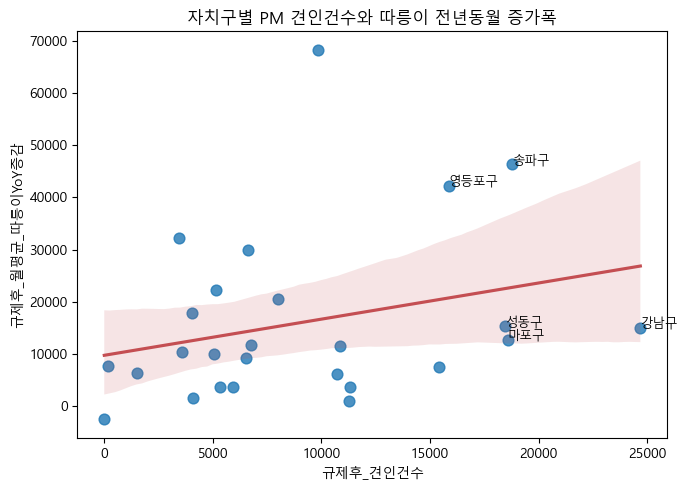

In [3]:
def corr_pair(x, y):
    s = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 3:
        return np.nan
    return np.corrcoef(s['x'], s['y'])[0, 1]

corr = pd.DataFrame([
    {'관계': '규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감', '상관계수': corr_pair(district['규제후_견인건수'], district['규제후_월평균_따릉이YoY증감'])},
    {'관계': '규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감', '상관계수': corr_pair(district['규제후_PM사고건수'], district['규제후_월평균_따릉이YoY증감'])},
])
display(corr)

plt.figure(figsize=(7, 5))
sns.regplot(data=district, x='규제후_견인건수', y='규제후_월평균_따릉이YoY증감', scatter_kws={'s': 60}, line_kws={'color': '#c44e52'})
for _, r in district.nlargest(5, '규제후_견인건수').iterrows():
    plt.text(r['규제후_견인건수'], r['규제후_월평균_따릉이YoY증감'], r['자치구'], fontsize=9)
plt.title('자치구별 PM 견인건수와 따릉이 전년동월 증가폭')
plt.tight_layout()
plt.show()


#### 결과 요약

**상관관계**

| 관계 | 상관계수 |
| --- | --- |
| 규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감 | 0.273 |
| 규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감 | 0.301 |
| PM 사고 직후 변화 vs 따릉이 YoY 직후 변화 | -0.201 |

**견인건수 상위 자치구**

| 자치구 | 규제후_견인건수 | 규제후_PM사고건수 | 규제후_월평균_따릉이YoY증감 | 규제후_월평균_따릉이YoY증감률 |
| --- | --- | --- | --- | --- |
| 강남구 | 24686.00 | 409.00 | 14877.49 | 21.43 |
| 송파구 | 18778.00 | 251.00 | 46433.56 | 28.83 |
| 마포구 | 18579.00 | 101.00 | 12668.54 | 12.28 |
| 성동구 | 18437.00 | 58.00 | 15258.39 | 17.98 |
| 영등포구 | 15862.00 | 82.00 | 42249.02 | 23.05 |
| 서초구 | 15428.00 | 117.00 | 7545.24 | 11.53 |
| 동작구 | 11332.00 | 74.00 | 3620.66 | 10.31 |
| 관악구 | 11263.00 | 78.00 | 869.29 | 5.21 |

- 자치구 단위에서도 PM 견인/사고가 큰 곳에서 따릉이 증가폭이 일관되게 커지는 대체효과는 뚜렷하지 않습니다.
- 따라서 기존 가설 3의 결론처럼 `PM 규제가 따릉이 이용 증가로 직접 전환되었다`고 보기는 어렵습니다.
- 보고서에서는 따릉이를 대체재라기보다 같은 도시 이동 수요가 집중되는 지역에서 함께 관찰되는 교통수단으로 해석하는 편이 안전합니다.